In [1]:
import os
import json
import pandas as pd
# from datetime import datetime
from dotenv import load_dotenv

from options import OptionSurface, Deribit, OKX, Bybit
from portfolio_management import Portfolio
from api_client import TradingDeskAPI
# from scanner import MarketScanner

In [2]:
# Initialize all classes and parameters

# load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
load_dotenv(r"C:/Users/brian/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
DATA_DIR = os.getenv("DATA_DIR")
FRACTION = float(os.getenv("FRACTION"))
MAX_POSITION = float(os.getenv("MAX_POSITION"))
ENTRY_EV_THRESHOLD = float(os.getenv("ENTRY_EV_THRESHOLD")) # require 1% edge, default = 0
EXIT_EV_THRESHOLD = float(os.getenv("EXIT_EV_THRESHOLD"))
print(BASE_URL)

with open(f"{DATA_DIR}/crypto_tag_ids.json", "r") as f:
    crypto_tag_ids = set(json.load(f))

s = OptionSurface()
portfolio = Portfolio()
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
# scanner = MarketScanner(api=api)

# target_expiry_str = "25DEC26"
# target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]
# currencies = ["BTC", "ETH", "HYPE", "SOL", "ZEC"]

https://alphasignal-dev.moretoncp.com


In [3]:
# 9. Get current markets
all_markets_df = api.get_all_markets(DATA_DIR=DATA_DIR, count_limit=10, liquidity_num_min=10000, volume_num_min=5000)
all_markets_df.head()

Fetched 100 markets | Total: 100
Fetched 100 markets | Total: 200
Fetched 100 markets | Total: 300
Fetched 100 markets | Total: 400
Fetched 100 markets | Total: 500
Fetched 100 markets | Total: 600
Fetched 100 markets | Total: 700
Fetched 100 markets | Total: 800
Fetched 100 markets | Total: 900
Fetched 100 markets | Total: 1,000


,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,oneHourPriceChange,umaResolutionStatus,eventStartTime,gameStartTime,groupItemRange
0,559651,Xi Jinping out before 2027?,0xa467b14d51f01b957109d9cbb1d6c124fab2a089d52e...,xi-jinping-out-before-2027,,2026-12-31T00:00:00Z,165852.97162,2025-07-03T20:37:00.228Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN
1,559652,Will Gavin Newsom win the 2028 Democratic pres...,0x0f49db97f71c68b1e42a6d16e3de93d85dbf7d4148e3...,will-gavin-newsom-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,300589.71633,2025-07-11T18:35:56.805Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
2,559653,Will Alexandria Ocasio-Cortez win the 2028 Dem...,0xe6bcc2f1dd025ce5e1833190f7c60a71171c94f805df...,will-alexandria-ocasio-cortez-win-the-2028-dem...,,2028-11-07T00:00:00Z,324397.56997,2025-07-11T18:35:59.075Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
3,559654,Will Pete Buttigieg win the 2028 Democratic pr...,0x4c325469d9b516ef4e6b8f73a81a12607dec075e3c2f...,will-pete-buttigieg-win-the-2028-democratic-pr...,,2028-11-07T00:00:00Z,523131.81014,2025-07-11T18:35:58.818Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN
4,559655,Will Josh Shapiro win the 2028 Democratic pres...,0xd65891729ce093cc12236856837eba1a0872fc7998fd...,will-josh-shapiro-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,477356.5287,2025-07-11T18:36:01.098Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2c3d7e0eee6f058be3006baabf0d54a07da254ba47fe...,,False,False,NaN,NaN,NaN,NaN,NaN


In [9]:
t = all_markets_df[all_markets_df["question"] == "Will Sung-Jae Im win the 2026 Masters tournament?"]
for i, j in t.iloc[0].items():
    print(i, j)

id 568695
question Will Sung-Jae Im win the 2026 Masters tournament?
conditionId 0xd8bf9a22e052cc97b14047a48552f3bd0e2605654e4fe580f48fa65e98d8487f
slug will-sung-jae-im-win-the-2026-masters-tournament
resolutionSource 
endDate 2026-04-13 00:00:00+00:00
liquidity 364848.02639
startDate 2025-08-29T04:15:39.808Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/pga-c332ca3e93.png
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/pga-c332ca3e93.png
description This polymarket will resolve according to the player who wins the 2026 Masters Tournament.

If this player is eliminated from contention for The Masters based on the official rules of the tournament, the relevant market will resolve to "No".

In the event of a tie, this market will resolve according to the official winner as determined by The Masters official tournament rules.

If no winner is announced by December 31, 2026, this market will resolve to "Other".

The primary resolution sources will be the official re

In [4]:
import re

cutoff = pd.Timestamp("2026-09-15", tz="UTC")
now = pd.Timestamp.now(tz="UTC")

all_markets_df["endDate"] = pd.to_datetime(all_markets_df["endDate"], utc=True)
filtered_df = all_markets_df[(all_markets_df["endDate"] < cutoff) & (all_markets_df["endDate"] > now)]
filtered_df

keywords = [
    "tennis",
    "sports"
]

pattern = "|".join(map(re.escape, keywords))

mask = (
    filtered_df["question"].fillna("").str.contains(pattern, case=False, regex=True)
    | filtered_df["description"].fillna("").str.contains(pattern, case=False, regex=True)
)

matches = filtered_df.loc[mask].copy()
matches

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,version,negRiskMarketID,seriesColor,showGmpSeries,showGmpOutcome,oneHourPriceChange,umaResolutionStatus,eventStartTime,gameStartTime,groupItemRange
875,1088472,Will Carlos Alcaraz win the 2026 Men's US Open?,0xcf4cf0cf9882b50018054826d561f688e319e6e51de9...,will-carlos-alcaraz-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,110127.7015,2026-01-02T20:36:54.374167Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x7db74de8403823823d4624b19d2b08fcbe53edc54e46...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
876,1088473,Will Novak Djokovic win the 2026 Men's US Open?,0x15f8f202d13a8bf70566cc9d015331f2b7c4673ce7c0...,will-novak-djokovic-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,75220.28903,2026-01-02T20:36:55.538507Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x7db74de8403823823d4624b19d2b08fcbe53edc54e46...,NaN,False,False,-0.0020,NaN,NaN,NaN,NaN
877,1088474,Will Jack Draper win the 2026 Men's US Open?,0x4f2f23afda0d87b57ed33b08385c13c105f5d4472c16...,will-jack-draper-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,168280.67477,2026-01-02T20:36:55.283939Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x7db74de8403823823d4624b19d2b08fcbe53edc54e46...,NaN,False,False,NaN,proposed,NaN,NaN,NaN
878,1088475,Will Alexander Zverev win the 2026 Men's US Open?,0x39b718f6e0a66a3ae5e459e76c74a694b521eaff5f60...,will-alexander-zverev-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,58561.15504,2026-01-02T20:36:57.65375Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x7db74de8403823823d4624b19d2b08fcbe53edc54e46...,NaN,False,False,0.0010,NaN,NaN,NaN,NaN
879,1088476,Will Ben Shelton win the 2026 Men's US Open?,0x5d1e8a08b738d682ce49308c73f0a83ae192476cc947...,will-ben-shelton-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,45677.78463,2026-01-02T20:36:57.14487Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x7db74de8403823823d4624b19d2b08fcbe53edc54e46...,NaN,False,False,0.0045,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,1088687,Will Alexandra Eala win the 2026 Women’s US Open?,0xd44a98cbfcf6b7b5727f6c880b8ef86f10d4a5b50b61...,will-alexandra-eala-win-the-2026-womens-us-open,NaN,2026-09-13 00:00:00+00:00,31944.22649,2026-01-02T20:36:05.754103Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2955e0b0325de182c7db3e9cc278b435a7e6956b599f...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
932,1088688,Will Beatriz Haddad Maia win the 2026 Women’s ...,0xe1c25af006f1f9c4da3f7b0047b2929c07e804c41043...,will-beatriz-haddad-maia-win-the-2026-womens-u...,NaN,2026-09-13 00:00:00+00:00,32721.59135,2026-01-02T20:36:07.397328Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2955e0b0325de182c7db3e9cc278b435a7e6956b599f...,NaN,False,False,NaN,disputed,NaN,NaN,NaN
933,1088689,Will Elise Mertens win the 2026 Women’s US Open?,0x8ed443ca250b535dee8b3b466414ac524bb62bf29cd9...,will-elise-mertens-win-the-2026-womens-us-open,NaN,2026-09-13 00:00:00+00:00,24711.83491,2026-01-02T20:36:07.14232Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,v1,0x2955e0b0325de182c7db3e9cc278b435a7e6956b599f...,NaN,False,False,NaN,NaN,NaN,NaN,NaN
934,1088690,Will Sofia Kenin win the 2026 Women’s US Open?,0x57bed6c99d9bde33590b2ef072d45623e60e679c32bf...,will-sofia-kenin-win-the-2026-womens-us-open,NaN,2026-09-13 00:00:00+00:00,25190.07697,2026-01-02T20:36:09.098354Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.

In [32]:
for _, row in matches.iterrows():
    print(row["question"])

Will Carlos Alcaraz win the 2026 Men's US Open?
Will Novak Djokovic win the 2026 Men's US Open?
Will Jack Draper win the 2026 Men's US Open?
Will Alexander Zverev win the 2026 Men's US Open?
Will Ben Shelton win the 2026 Men's US Open?
Will Taylor Fritz win the 2026 Men's US Open?
Will Daniil Medvedev win the 2026 Men's US Open?
Will Joao Fonseca win the 2026 Men's US Open?
Will Felix Auger Aliassime win the 2026 Men's US Open?
Will Jakub Mensik win the 2026 Men's US Open?
Will Alexander Bublik win the 2026 Men's US Open?
Will Lorenzo Musetti win the 2026 Men's US Open?
Will Holger Rune win the 2026 Men's US Open?
Will Arthur Fils win the 2026 Men's US Open?
Will Jiri Lehecka win the 2026 Men's US Open?
Will Flavio Cobolli win the 2026 Men's US Open?
Will Matteo Berrettini win the 2026 Men's US Open?
Will Andrey Rublev win the 2026 Men's US Open?
Will Frances Tiafoe win the 2026 Men's US Open?
Will Hubert Hurkacz win the 2026 Men's US Open?
Will Grigor Dimitrov win the 2026 Men's US Op

In [6]:
scanner = MarketScanner(api)
markets_df = scanner.scan_market(matches)
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,groupItemRange,tokens,yes_token,no_token,yes_book,no_book,yes_bid,yes_ask,no_bid,no_ask
875,1088472,Will Carlos Alcaraz win the 2026 Men's US Open?,0xcf4cf0cf9882b50018054826d561f688e319e6e51de9...,will-carlos-alcaraz-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,110127.7015,2026-01-02T20:36:54.374167Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[714019040102474277543297842779242058418204608...,7140190401024742775432978427792420584182046086...,9026469324102605102307422463289059933747503876...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,0.3,0.31,0.69,0.7
876,1088473,Will Novak Djokovic win the 2026 Men's US Open?,0x15f8f202d13a8bf70566cc9d015331f2b7c4673ce7c0...,will-novak-djokovic-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,75220.28903,2026-01-02T20:36:55.538507Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[600390413506193654779071376265016028728396868...,6003904135061936547790713762650160287283968685...,4536867253252639327837432609699436444183932860...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,0.112,0.12,0.88,0.888
877,1088474,Will Jack Draper win the 2026 Men's US Open?,0x4f2f23afda0d87b57ed33b08385c13c105f5d4472c16...,will-jack-draper-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,168280.67477,2026-01-02T20:36:55.283939Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[568177215018882009954451150140516930376097061...,5681772150188820099544511501405169303760970611...,3578909154344077780822139434936602727164605640...,{'market': '0x4f2f23afda0d87b57ed33b08385c13c1...,{'market': '0x4f2f23afda0d87b57ed33b08385c13c1...,NaN,0.001,0.999,NaN
878,1088475,Will Alexander Zverev win the 2026 Men's US Open?,0x39b718f6e0a66a3ae5e459e76c74a694b521eaff5f60...,will-alexander-zverev-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,58561.15504,2026-01-02T20:36:57.65375Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[104580986699278831852048284535710655508746366...,1045809866992788318520482845357106555087463669...,5579491013191873260814332580873160835053832378...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,0.207,0.209,0.791,0.793
879,1088476,Will Ben Shelton win the 2026 Men's US Open?,0x5d1e8a08b738d682ce49308c73f0a83ae192476cc947...,will-ben-shelton-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,45677.78463,2026-01-02T20:36:57.14487Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[974253735425412444092791481680358030420847835...,9742537354254124440927914816803580304208478352...,7911530330448449060034990308171335148228099323...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,0.078,0.09,0.91,0.922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,1088687,Will Alexandra Eala win the 2026 Women’s US Open?,0xd44a98cbfcf6b7b5727f6c880b8ef86f10d4a5b50b61...,will-alexandra-eala-win-the-2026-womens-us-open,NaN,2026-09-13 00:00:00+00:00,31944.22649,2026-01-02T20:36:05.754103Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,[809019102775209120336679990691660968457108758...,8090191027752091203366799906916609684571087583...,2629909651874454835006797332492039434382564121...,{'market': '0xd44a98cbfcf6b7b5727f6c880b8ef86f...,{'market': '0xd44a98cbfcf6b7b5727f6c880b8ef86f...,0.035,0.036,0.964,0.965
932,1088688,Will Beatriz Haddad Maia win the 2026 Women’s ...,0xe1c25af006f1f9c4da3f7b0047b2929c07e804c41

In [14]:
markets_df["player"] = markets_df["question"].str.extract(r"^Will (.*?) win the 2026", expand=False)
markets_df["gender"] = markets_df["question"].str.extract(
    r"^Will .* win the 2026 (Men|Women)[’']s US Open",
    expand=False
)
markets_df = markets_df.dropna(subset="yes_bid")

In [13]:
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,yes_token,no_token,yes_book,no_book,yes_bid,yes_ask,no_bid,no_ask,player,gender
875,1088472,Will Carlos Alcaraz win the 2026 Men's US Open?,0xcf4cf0cf9882b50018054826d561f688e319e6e51de9...,will-carlos-alcaraz-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,110127.7015,2026-01-02T20:36:54.374167Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,7140190401024742775432978427792420584182046086...,9026469324102605102307422463289059933747503876...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,0.3,0.31,0.69,0.7,Carlos Alcaraz,Men
876,1088473,Will Novak Djokovic win the 2026 Men's US Open?,0x15f8f202d13a8bf70566cc9d015331f2b7c4673ce7c0...,will-novak-djokovic-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,75220.28903,2026-01-02T20:36:55.538507Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,6003904135061936547790713762650160287283968685...,4536867253252639327837432609699436444183932860...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,0.112,0.12,0.88,0.888,Novak Djokovic,Men
877,1088474,Will Jack Draper win the 2026 Men's US Open?,0x4f2f23afda0d87b57ed33b08385c13c105f5d4472c16...,will-jack-draper-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,168280.67477,2026-01-02T20:36:55.283939Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,5681772150188820099544511501405169303760970611...,3578909154344077780822139434936602727164605640...,{'market': '0x4f2f23afda0d87b57ed33b08385c13c1...,{'market': '0x4f2f23afda0d87b57ed33b08385c13c1...,NaN,0.001,0.999,NaN,Jack Draper,Men
878,1088475,Will Alexander Zverev win the 2026 Men's US Open?,0x39b718f6e0a66a3ae5e459e76c74a694b521eaff5f60...,will-alexander-zverev-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,58561.15504,2026-01-02T20:36:57.65375Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1045809866992788318520482845357106555087463669...,5579491013191873260814332580873160835053832378...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,0.207,0.209,0.791,0.793,Alexander Zverev,Men
879,1088476,Will Ben Shelton win the 2026 Men's US Open?,0x5d1e8a08b738d682ce49308c73f0a83ae192476cc947...,will-ben-shelton-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,45677.78463,2026-01-02T20:36:57.14487Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,9742537354254124440927914816803580304208478352...,7911530330448449060034990308171335148228099323...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,0.078,0.09,0.91,0.922,Ben Shelton,Men
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,1088687,Will Alexandra Eala win the 2026 Women’s US Open?,0xd44a98cbfcf6b7b5727f6c880b8ef86f10d4a5b50b61...,will-alexandra-eala-win-the-2026-womens-us-open,NaN,2026-09-13 00:00:00+00:00,31944.22649,2026-01-02T20:36:05.754103Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,8090191027752091203366799906916609684571087583...,2629909651874454835006797332492039434382564121...,{'market': '0xd44a98cbfcf6b7b5727f6c880b8ef86f...,{'market': '0xd44a98cbfcf6b7b5727f6c880b8ef86f...,0.035,0.036,0.964,0.965,Alexandra Eala,Women
932,1088688,Will Beatriz Haddad Maia win the 2026 Women’s ...,0xe1c25af006f1f9c4da3f7b0047b2929c07e804c41043...,will-beatriz-haddad-maia-win-the-2026-womens-u...,NaN,2026-09-13 00:00:00+00:00,32721.59135,2026-01-02T20:36:07.397328Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amaz

In [43]:
markets_df["createdAt"] = pd.to_datetime(markets_df["createdAt"], utc=True)
markets_df["endDate"] = pd.to_datetime(markets_df["endDate"], utc=True)

In [80]:
markets_df.iloc[1]["description"]

'This market will resolve according to the exact amount of cuts of 25 basis points in 2026 by the Fed (including any cuts made during the December meeting).\n\nEmergency rate cuts outside of scheduled FOMC meetings will also count toward the total number of cuts in 2026. This market will remain open until December 31, 2026, 11:59 PM ET, to account for any such emergency actions.\n\nFor example, if the Fed cuts rates by 50 bps after a meeting, it would be considered 2 cuts (of 25 bps each).\n\nThis market will resolve early to "No" if the specified number of cuts becomes impossible — i.e., if more cuts have already occurred than the strike in question.\n\nNote that cuts between 1–24 bps (inclusive) will also be considered 1 rate cut.\n\nThe resolution source for this market will be FOMC statements after meetings scheduled in 2026 according to the official calendar: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. The level and change of the target federal funds rate is a

In [15]:
markets_df

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,yes_token,no_token,yes_book,no_book,yes_bid,yes_ask,no_bid,no_ask,player,gender
875,1088472,Will Carlos Alcaraz win the 2026 Men's US Open?,0xcf4cf0cf9882b50018054826d561f688e319e6e51de9...,will-carlos-alcaraz-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,110127.7015,2026-01-02T20:36:54.374167Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,7140190401024742775432978427792420584182046086...,9026469324102605102307422463289059933747503876...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,{'market': '0xcf4cf0cf9882b50018054826d561f688...,0.3,0.31,0.69,0.7,Carlos Alcaraz,Men
876,1088473,Will Novak Djokovic win the 2026 Men's US Open?,0x15f8f202d13a8bf70566cc9d015331f2b7c4673ce7c0...,will-novak-djokovic-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,75220.28903,2026-01-02T20:36:55.538507Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,6003904135061936547790713762650160287283968685...,4536867253252639327837432609699436444183932860...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,{'market': '0x15f8f202d13a8bf70566cc9d015331f2...,0.112,0.12,0.88,0.888,Novak Djokovic,Men
878,1088475,Will Alexander Zverev win the 2026 Men's US Open?,0x39b718f6e0a66a3ae5e459e76c74a694b521eaff5f60...,will-alexander-zverev-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,58561.15504,2026-01-02T20:36:57.65375Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1045809866992788318520482845357106555087463669...,5579491013191873260814332580873160835053832378...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,{'market': '0x39b718f6e0a66a3ae5e459e76c74a694...,0.207,0.209,0.791,0.793,Alexander Zverev,Men
879,1088476,Will Ben Shelton win the 2026 Men's US Open?,0x5d1e8a08b738d682ce49308c73f0a83ae192476cc947...,will-ben-shelton-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,45677.78463,2026-01-02T20:36:57.14487Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,9742537354254124440927914816803580304208478352...,7911530330448449060034990308171335148228099323...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,{'market': '0x5d1e8a08b738d682ce49308c73f0a83a...,0.078,0.09,0.91,0.922,Ben Shelton,Men
880,1088477,Will Taylor Fritz win the 2026 Men's US Open?,0x1e8287101399f3c9c1c135d82f7e53613a4ba421cab1...,will-taylor-fritz-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,82789.5101,2026-01-02T20:36:57.399288Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,7336448317231926439490571939875059421420455504...,1052661135554828744476923847401839903120493589...,{'market': '0x1e8287101399f3c9c1c135d82f7e5361...,{'market': '0x1e8287101399f3c9c1c135d82f7e5361...,0.056,0.057,0.943,0.944,Taylor Fritz,Men
881,1088478,Will Daniil Medvedev win the 2026 Men's US Open?,0x2212033b5adefa053fe4c71067daa55118aa7e97cd95...,will-daniil-medvedev-win-the-2026-mens-us-open,NaN,2026-09-13 00:00:00+00:00,70572.70978,2026-01-02T20:36:59.144255Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1007730595729106464599527610749437191934780589...,3813637451724327817449836141114087226041245328...,{'market': '0x2212033b5adefa053fe4c71067daa551...,{'market': '0x2212033b5adefa053fe4c71067daa551...,0.027,0.028,0.972,0.973,Daniil Medvedev,Men
883,1088480,Will Felix Auger Aliassime win the 2026 Men's ...,0xf7c252ad31286ada89db99be13597440c560902399c7...,will-felix-auger-aliassime-win-the-2026-mens-u...,NaN,2026-09-13 00:00:00+00:00,62079.87001,2026-01-02T20:37:02.106197Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,3263749140286239754836851172103403743931865058...,1021245811478788494170139

In [21]:
men = markets_df[markets_df["gender"] == "Men"].copy()

men[
    [
        "player",
        "yes_bid",
        "yes_ask",
        "no_bid",
        "no_ask",
    ]
].sort_values("yes_ask")

,player,yes_bid,yes_ask,no_bid,no_ask
895,Grigor Dimitrov,0.003,0.004,0.996,0.997
891,Matteo Berrettini,0.003,0.004,0.996,0.997
894,Hubert Hurkacz,0.003,0.004,0.996,0.997
892,Andrey Rublev,0.005,0.007,0.993,0.995
885,Alexander Bublik,0.005,0.007,0.993,0.995
889,Jiri Lehecka,0.008,0.009,0.991,0.992
886,Lorenzo Musetti,0.01,0.011,0.989,0.99
890,Flavio Cobolli,0.013,0.015,0.985,0.987
884,Jakub Mensik,0.02,0.024,0.976,0.98
893,Frances Tiafoe,0.023,0.024,0.976,0.977


In [70]:
for i, j in men.iloc[0].items():
    print(i, j)

id 1088472
question Will Carlos Alcaraz win the 2026 Men's US Open?
conditionId 0xcf4cf0cf9882b50018054826d561f688e319e6e51de956437fa6dbf642696a40
slug will-carlos-alcaraz-win-the-2026-mens-us-open
resolutionSource nan
endDate 2026-09-13 00:00:00+00:00
liquidity 110127.7015
startDate 2026-01-02T20:36:54.374167Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/2026-mens-us-open-winner-tennis-oSTkkDpgQu-b.png
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/2026-mens-us-open-winner-tennis-oSTkkDpgQu-b.png
description The 2026 U.S. Open tennis tournament is scheduled for August 23 - September 13, 2026.

This market will resolve to the player that wins the 2026 U.S. Open Men’s Singles Tournament.

If at any point it becomes impossible for a listed player to win the 2026 U.S. Open Men’s Singles Tournament per the rules of the tournament, the corresponding market will resolve to “No”.

If the 2026 U.S. Open Men’s Singles Tournament is cancelled, postponed after October 31,

In [ ]:
sum_series = (
    price_history_df.groupby("timestamp")["price"]
    .sum()
)

gender
Men      1.037
Women    1.086
Name: yes_ask, dtype: object

In [28]:
import time
from datetime import datetime, timezone
import requests
def get_price_history(
    token_id: str,
    start_ts: int,
    end_ts: int,
    interval="1m",
    fidelity=10,
):
    url = "https://clob.polymarket.com/prices-history"

    params = {
        "market": token_id,
        "startTs": start_ts,
        "endTs": end_ts,
        "interval": interval,
        "fidelity": fidelity,
    }

    r = requests.get(url, params=params, timeout=30)

    if not r.ok:
        raise RuntimeError(
            f"{r.status_code}: {r.text}"
        )

    return r.json()["history"]


def get_history_chunked(
    token_id: str,
    start_ts: int,
    end_ts: int,
    chunk_days=1,
):
    all_history = []

    chunk_seconds = chunk_days * 24 * 60 * 60

    current = start_ts

    while current < end_ts:
        chunk_end = min(
            current + chunk_seconds,
            end_ts
        )

        print(
            datetime.fromtimestamp(
                current, tz=timezone.utc
            ),
            "->",
            datetime.fromtimestamp(
                chunk_end, tz=timezone.utc
            )
        )

        history = get_price_history(
            token_id,
            current,
            chunk_end,
        )

        all_history.extend(history)

        current = chunk_end

    # Convert to dataframe
    df = pd.DataFrame(all_history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(
        df["t"],
        unit="s",
        utc=True
    )

    df["price"] = df["p"].astype(float)

    df = df[
        ["timestamp", "price"]
    ]

    # Remove duplicate timestamps caused by chunk boundaries
    df = (
        df
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return df
    
df = markets_df.copy()

now_ts = int(time.time())

all_market_history = {}

for idx, row in df.iterrows():

    token_id = row["yes_token"]

    # Convert createdAt -> Unix timestamp
    created_at = pd.to_datetime(row["createdAt"])
    start_ts = int(created_at.timestamp())

    print("\n" + "=" * 80)
    print(f"Market: {row['question']}")
    print(f"Created: {created_at}")
    print(
        f"Start: {datetime.fromtimestamp(start_ts, tz=timezone.utc)}"
    )

    try:
        history = get_history_chunked(
            token_id=token_id,
            start_ts=start_ts,
            end_ts=now_ts,
            chunk_days=15
        )

        # Keep market metadata
        history["market_index"] = idx
        history["question"] = row["question"]
        history["token_id"] = token_id

        all_market_history[idx] = history

        print(f"Downloaded {len(history):,} observations")

    except Exception as e:
        print(f"ERROR: {e}")

price_history_df = pd.concat(
    all_market_history.values(),
    ignore_index=True
)

print(price_history_df.head())
print(price_history_df.shape)


Market: Will Carlos Alcaraz win the 2026 Men's US Open?
Created: 2026-01-02 17:59:43.884641+00:00
Start: 2026-01-02 17:59:43+00:00
2026-01-02 17:59:43+00:00 -> 2026-01-17 17:59:43+00:00
2026-01-17 17:59:43+00:00 -> 2026-02-01 17:59:43+00:00
2026-02-01 17:59:43+00:00 -> 2026-02-16 17:59:43+00:00
2026-02-16 17:59:43+00:00 -> 2026-03-03 17:59:43+00:00
2026-03-03 17:59:43+00:00 -> 2026-03-18 17:59:43+00:00
2026-03-18 17:59:43+00:00 -> 2026-04-02 17:59:43+00:00
2026-04-02 17:59:43+00:00 -> 2026-04-17 17:59:43+00:00
2026-04-17 17:59:43+00:00 -> 2026-05-02 17:59:43+00:00
2026-05-02 17:59:43+00:00 -> 2026-05-17 17:59:43+00:00
2026-05-17 17:59:43+00:00 -> 2026-06-01 17:59:43+00:00
2026-06-01 17:59:43+00:00 -> 2026-06-16 17:59:43+00:00
2026-06-16 17:59:43+00:00 -> 2026-07-01 17:59:43+00:00
2026-07-01 17:59:43+00:00 -> 2026-07-16 17:59:43+00:00
2026-07-16 17:59:43+00:00 -> 2026-07-31 17:59:43+00:00
2026-07-31 17:59:43+00:00 -> 2026-08-15 17:59:43+00:00
2026-08-15 17:59:43+00:00 -> 2026-08-26 06:

In [48]:
price_history_df = pd.read_parquet("tennis_price_history_df.parquet")
price_history_df = (
    price_history_df.set_index("timestamp")
      .groupby("token_id")
      .resample("10min")
      .agg({
          "price": "last",
          "market_index": "first",
          "question": "first",
      })
      .reset_index()
)
price_history_df

,token_id,timestamp,price,market_index,question
0,1002087609790068157008213655546239890485855419...,2026-01-02 21:00:00+00:00,0.460,925.0,Will Donna Vekic win the 2026 Women’s US Open?
1,1002087609790068157008213655546239890485855419...,2026-01-02 21:10:00+00:00,0.445,925.0,Will Donna Vekic win the 2026 Women’s US Open?
2,1002087609790068157008213655546239890485855419...,2026-01-02 21:20:00+00:00,0.410,925.0,Will Donna Vekic win the 2026 Women’s US Open?
3,1002087609790068157008213655546239890485855419...,2026-01-02 21:30:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
4,1002087609790068157008213655546239890485855419...,2026-01-02 21:40:00+00:00,0.050,925.0,Will Donna Vekic win the 2026 Women’s US Open?
...,...,...,...,...,...
1762670,9802550207568138353041385750563535019776718188...,2026-08-26 05:50:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762671,9802550207568138353041385750563535019776718188...,2026-08-26 06:00:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762672,9802550207568138353041385750563535019776718188...,2026-08-26 06:10:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?
1762673,9802550207568138353041385750563535019776718188...,2026-08-26 06:20:00+00:00,0.007,912.0,Will Belinda Bencic win the 2026 Women’s US Open?


In [51]:
import numpy as np
import pandas as pd

df = price_history_df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = (
    df[
        df["price"].between(0, 1)
    ]
    .sort_values(["token_id", "timestamp"])
    .copy()
)

# ---------------------------------------------------------
# 1. Resample to exact 10-minute intervals
# ---------------------------------------------------------

df = (
    df.set_index("timestamp")
      .groupby("token_id")["price"]
      .resample("10min")
      .last()
      .dropna()
      .reset_index()
)

# ---------------------------------------------------------
# 2. Logit transform
# ---------------------------------------------------------

eps = 0.001

p = df["price"].clip(eps, 1 - eps)

df["logit"] = np.log(p / (1 - p))


# ---------------------------------------------------------
# 3. Rolling 24-hour z-score
# ---------------------------------------------------------

# 24 hours = 144 ten-minute observations
window = 144

g = df.groupby("token_id")["logit"]

df["rolling_mean"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).mean()
    )
)

df["rolling_std"] = (
    g.transform(
        lambda x:
        x.rolling(
            window,
            min_periods=72
        ).std()
    )
)

df["zscore"] = (
    (df["logit"] - df["rolling_mean"])
    / df["rolling_std"]
)


# ---------------------------------------------------------
# 4. Future logit changes
# ---------------------------------------------------------

g_logit = df.groupby("token_id")["logit"]

for name, periods in {
    "1h": 6,
    "6h": 36,
    "24h": 144,
    "3d": 432,
}.items():

    df[f"future_logit_{name}"] = (
        g_logit.shift(-periods)
        - df["logit"]
    )

In [53]:
for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] < -2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

for horizon in ["1h", "6h", "24h", "3d"]:

    signal = df["zscore"] > 2

    result = df.loc[
        signal,
        f"future_logit_{horizon}"
    ].dropna()

    print(
        f"{horizon:>4}",
        f"N={len(result):>7,}",
        f"mean={result.mean():+.5f}",
        f"median={result.median():+.5f}",
        f"win={(result > 0).mean():.3f}"
    )

  1h N= 84,245 mean=+0.00403 median=+0.00000 win=0.136
  6h N= 84,244 mean=-0.00364 median=+0.00000 win=0.233
 24h N= 83,869 mean=-0.01005 median=+0.00000 win=0.326
  3d N= 83,349 mean=-0.04760 median=+0.00000 win=0.357
  1h N= 56,715 mean=-0.03103 median=+0.00000 win=0.101
  6h N= 56,579 mean=-0.06682 median=+0.00000 win=0.159
 24h N= 56,334 mean=-0.12177 median=-0.02032 win=0.233
  3d N= 55,592 mean=-0.17258 median=-0.06504 win=0.267


In [112]:
market_index = 875

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

alcaraz = (
    price_history_df[
        price_history_df["question"]
        == "Will Carlos Alcaraz win the 2026 Men's US Open?"
    ]
    .copy()
)

alcaraz["timestamp"] = pd.to_datetime(
    alcaraz["timestamp"],
    utc=True
)

alcaraz["price"] = pd.to_numeric(
    alcaraz["price"],
    errors="coerce"
)

alcaraz = (
    alcaraz
    .sort_values("timestamp")
    .reset_index(drop=True)
)

alcaraz.head()

alcaraz["change"] = (
    alcaraz["price"].diff()
)

alcaraz["pct_change"] = (
    alcaraz["price"].pct_change()
)

alcaraz[
    ["timestamp", "price", "change", "pct_change"]
].head(30)

,timestamp,price,change,pct_change
0,2026-01-02 21:00:00+00:00,0.500,NaN,NaN
1,2026-01-02 21:10:00+00:00,0.485,-0.015,-0.030000
2,2026-01-02 21:20:00+00:00,0.465,-0.020,-0.041237
3,2026-01-02 21:30:00+00:00,0.455,-0.010,-0.021505
4,2026-01-02 21:40:00+00:00,0.470,0.015,0.032967
5,2026-01-02 21:50:00+00:00,0.560,0.090,0.191489
6,2026-01-02 22:00:00+00:00,0.560,0.000,0.000000
7,2026-01-02 22:10:00+00:00,0.545,-0.015,-0.026786
8,2026-01-02 22:20:00+00:00,0.525,-0.020,-0.036697
9,2026-01-02 22:30:00+00:00,0.510,-0.015,-0.028571


In [113]:
# Make sure sorted
alcaraz = alcaraz.sort_values("timestamp").reset_index(drop=True)

# Future absolute price changes
for name, periods in {
    "10m": 1,
    "30m": 3,
    "1h": 6,
    "6h": 36,
    "24h": 144,
    "3d": 432,
}.items():

    alcaraz[f"future_change_{name}"] = (
        alcaraz["price"].shift(-periods)
        - alcaraz["price"]
    )

for name in ["10m", "30m", "1h", "6h", "24h", "3d"]:

    alcaraz[f"future_return_{name}"] = (
        alcaraz[f"future_change_{name}"]
        / alcaraz["price"]
    )

In [114]:
signal = alcaraz["change"] >= 0.02

for horizon in [
    "10m",
    "30m",
    "1h",
    "6h",
    "24h"
]:

    x = alcaraz.loc[
        signal,
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x > 0).mean()
    )

10m N = 73 mean = -0.0015753424657534256 median = 0.0 win = 0.1917808219178082
30m N = 73 mean = -0.006438356164383562 median = 0.0 win = 0.2191780821917808
1h N = 73 mean = -0.007054794520547947 median = 0.0 win = 0.2191780821917808
6h N = 73 mean = -0.013972602739726028 median = -0.0050000000000000044 win = 0.2328767123287671
24h N = 73 mean = -0.008287671232876718 median = -0.0050000000000000044 win = 0.3424657534246575


In [115]:
signal = alcaraz["change"] <= -0.02

for horizon in [
    "10m",
    "30m",
    "1h",
    "6h",
    "24h"
]:

    x = alcaraz.loc[
        signal,
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x < 0).mean()
    )

10m N = 63 mean = 7.936507936508031e-05 median = 0.0 win = 0.19047619047619047
30m N = 63 mean = -0.0026190476190476168 median = 0.0 win = 0.2857142857142857
1h N = 63 mean = -0.004047619047619044 median = 0.0 win = 0.3492063492063492
6h N = 63 mean = -0.00968253968253968 median = 0.0 win = 0.42857142857142855
24h N = 63 mean = 0.004285714285714283 median = 0.0 win = 0.4444444444444444


In [117]:
len(alcaraz)

32916

In [116]:
alcaraz["past_1h"] = (
    alcaraz["price"]
    - alcaraz["price"].shift(6)
)
bins = [
    -np.inf,
    -0.10,
    -0.05,
    -0.03,
    -0.02,
    -0.01,
    -0.005,
     0,
     0.005,
     0.01,
     0.02,
     0.03,
     0.05,
     0.10,
     np.inf
]

alcaraz["shock_bucket"] = pd.cut(
    alcaraz["past_1h"],
    bins=bins
)

result = (
    alcaraz
    .groupby("shock_bucket", observed=True)
    .agg(
        n=("price", "size"),
        mean_move=("past_1h", "mean"),
        future_10m=("future_change_10m", "mean"),
        future_30m=("future_change_30m", "mean"),
        future_1h=("future_change_1h", "mean"),
        future_6h=("future_change_6h", "mean"),
        future_24h=("future_change_24h", "mean"),
    )
)

result

# Small/moderate movements mean-revert, while very large movements are information shocks.

,n,mean_move,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,,
"(-inf, -0.1]",9,-0.166111,-0.000556,-0.006667,2.222222e-03,-0.007778,0.012222
"(-0.1, -0.05]",48,-0.067917,-0.006042,-0.010104,-1.218750e-02,-0.017188,-0.003021
"(-0.05, -0.03]",83,-0.037711,0.000301,-0.000482,1.144578e-03,0.001506,0.024337
"(-0.03, -0.02]",207,-0.022947,0.000942,0.000507,9.385943e-19,-0.001329,0.012077
"(-0.02, -0.01]",834,-0.012074,0.000677,0.001121,1.312950e-03,0.003046,0.005296
"(-0.01, -0.005]",2166,-0.005402,0.001041,0.000843,5.378578e-04,0.000819,0.001556
"(-0.005, 0.0]",26290,-0.000046,0.000021,0.000051,9.492467e-05,0.000142,-0.000585
"(0.0, 0.005]",214,0.005000,-0.000421,-0.000117,-2.570093e-04,0.004579,0.009790
"(0.005, 0.01]",1981,0.005472,-0.001095,-0.001146,-1.607774e-03,-0.003556,-0.002943


In [89]:
print(
    alcaraz[
        ["timestamp", "price", "future_price_10m"]
    ].head(10)
)

                  timestamp  price  future_price_10m
0 2026-01-02 21:00:00+00:00  0.500             0.485
1 2026-01-02 21:10:00+00:00  0.485             0.465
2 2026-01-02 21:20:00+00:00  0.465             0.455
3 2026-01-02 21:30:00+00:00  0.455             0.470
4 2026-01-02 21:40:00+00:00  0.470             0.560
5 2026-01-02 21:50:00+00:00  0.560             0.560
6 2026-01-02 22:00:00+00:00  0.560             0.545
7 2026-01-02 22:10:00+00:00  0.545             0.525
8 2026-01-02 22:20:00+00:00  0.525             0.510
9 2026-01-02 22:30:00+00:00  0.510             0.505


In [82]:
alcaraz["signal_raw"] = (
    alcaraz["past_1h"] >= 0.01
)
alcaraz["signal_start"] = (
    alcaraz["signal_raw"]
    & ~alcaraz["signal_raw"].shift(1).fillna(False)
)

signals = alcaraz[
    alcaraz["signal_start"]
].copy()

signals = signals[
    signals["past_1h"] >= 0.01
].copy()

for horizon in ["10m", "30m", "1h", "6h", "24h"]:
    x = signals[
        f"future_change_{horizon}"
    ].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x < 0).mean()
    )

10m N = 1078 mean = -0.0012105751391465684 median = 0.0 win = 0.21706864564007422
30m N = 1078 mean = -0.0018970315398886839 median = 0.0 win = 0.2847866419294991
1h N = 1078 mean = -0.002184601113172543 median = 0.0 win = 0.3320964749536178
6h N = 1078 mean = -0.004466604823747682 median = 0.0 win = 0.45454545454545453
24h N = 1072 mean = -0.004556902985074631 median = -0.0050000000000000044 win = 0.5466417910447762


In [120]:
horizons = {
    "10m": 1,
    "30m": 3,
    "1h": 6,
    "6h": 36,
    "24h": 144,
}

for name, periods in horizons.items():
    alcaraz[f"future_price_{name}"] = (
        alcaraz["price"].shift(-periods)
    )

In [85]:
alcaraz

,token_id,timestamp,price,market_index,question,change,pct_change,future_change_10m,future_change_30m,future_change_1h,...,future_return_3d,past_1h,past_1h_bucket,signal_raw,signal_start,future_price_10m,future_price_30m,future_price_1h,future_price_6h,future_price_24h
0,7140190401024742775432978427792420584182046086...,2026-01-02 21:00:00+00:00,0.500,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,NaN,NaN,-0.015,-0.045,0.060,...,-0.190000,NaN,NaN,False,False,0.485,0.455,0.560,0.360,0.41
1,7140190401024742775432978427792420584182046086...,2026-01-02 21:10:00+00:00,0.485,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.015,-0.030000,-0.020,-0.015,0.060,...,-0.206186,NaN,NaN,False,False,0.465,0.470,0.545,0.355,0.41
2,7140190401024742775432978427792420584182046086...,2026-01-02 21:20:00+00:00,0.465,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.020,-0.041237,-0.010,0.095,0.060,...,-0.172043,NaN,NaN,False,False,0.455,0.560,0.525,0.350,0.41
3,7140190401024742775432978427792420584182046086...,2026-01-02 21:30:00+00:00,0.455,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,-0.010,-0.021505,0.015,0.105,0.055,...,-0.153846,NaN,NaN,False,False,0.470,0.560,0.510,0.345,0.41
4,7140190401024742775432978427792420584182046086...,2026-01-02 21:40:00+00:00,0.470,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.015,0.032967,0.090,0.075,0.035,...,-0.180851,NaN,NaN,False,False,0.560,0.545,0.505,0.345,0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32911,7140190401024742775432978427792420584182046086...,2026-08-26 05:40:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,0.000,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,0.305,NaN,NaN,NaN
32912,7140190401024742775432978427792420584182046086...,2026-08-26 05:50:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,0.000,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,0.305,NaN,NaN,NaN
32913,7140190401024742775432978427792420584182046086...,2026-08-26 06:00:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,NaN,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,NaN,NaN,NaN,NaN
32914,7140190401024742775432978427792420584182046086...,2026-08-26 06:10:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?,0.000,0.000000,0.000,NaN,NaN,...,NaN,0.0,"(-0.005, 0.0]",False,False,0.305,NaN,NaN,NaN,NaN


In [ ]:
def fee(price):
    return 0.03 * price * (1 - price)

def sortino(x, target=0):
    x = pd.Series(x).dropna()

    downside = np.minimum(x - target, 0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_dev == 0:
        return np.nan

    return (
        x.mean() - target
    ) / downside_dev

spread = 0.01
half_spread = spread / 2

thresholds = [
    0.005,
    0.01,
    0.015,
    0.02,
    0.03,
    0.05,
    0.10
]

horizons = ["10m", "30m", "1h", "6h", "24h"]

results = []

for bucket, s in alcaraz.groupby("shock_bucket", observed=True):

    # Signal
    # signal_raw = alcaraz["past_1h"] >= threshold

    # # Only enter when signal first appears
    # signal_start = (
    #     signal_raw
    #     & ~signal_raw.shift(1).fillna(False)
    # )
    s = s.copy()
    # s = alcaraz[signal_start].copy()

    # -------------------------
    # ENTRY: BUY NO
    # -------------------------

    s["entry_no"] = (
        1 - s["price"] + half_spread
    )

    s["entry_fee"] = fee(s["entry_no"])

    for horizon in horizons:

        # -------------------------
        # EXIT: SELL NO
        # -------------------------

        s["exit_no"] = (
            1
            - s[f"future_price_{horizon}"]
            - half_spread
        )

        # -------------------------
        # GROSS P&L
        # -------------------------

        s["gross_pnl"] = (
            s["exit_no"]
            - s["entry_no"]
        )

        # -------------------------
        # EXIT FEE
        # -------------------------

        s["exit_fee"] = fee(s["exit_no"])

        # -------------------------
        # NET P&L
        # -------------------------

        s["net_pnl"] = (
            s["gross_pnl"]
            - s["entry_fee"]
            - s["exit_fee"]
        )

        s["return"] = (
            s["net_pnl"]
            / s["entry_no"]
        )

        x = s["net_pnl"].dropna()

        print(
        bucket,
        "h", horizon,
        "N =", len(s.dropna(subset=["return"])),
        "mean =", s["return"].mean(),
        "sortino =", sortino(s["return"])
    )

        # results.append({
        #     "threshold": threshold,
        #     "horizon": horizon,
        #     "N": len(x),
        #     "mean": x.mean(),
        #     "median": x.median(),
        #     "win_rate": (x > 0).mean(),
        #     "std": x.std()
        # })

results_df = pd.DataFrame(results)

# Small and moderate shocks exhibit statistically negative subsequent price changes, but the edge is too small to overcome transaction costs. Very large shocks may contain a tradable mean-reversion signal, particularly at longer horizons.

(-inf, -0.1] h 10m N = 9 mean = -0.03360099667222004 sortino = -0.9683336066092952
(-inf, -0.1] h 30m N = 9 mean = -0.023062682555780936 sortino = -0.8090053464630046
(-inf, -0.1] h 1h N = 9 mean = -0.03590327545960914 sortino = -0.6768423751310332
(-inf, -0.1] h 6h N = 9 mean = -0.01961662749874085 sortino = -0.2610378312365185
(-inf, -0.1] h 24h N = 9 mean = -0.0523111846586758 sortino = -0.5704215247855136
(-0.1, -0.05] h 10m N = 48 mean = -0.02244348311501602 sortino = -0.7788911987373833
(-0.1, -0.05] h 30m N = 48 mean = -0.016257373644774115 sortino = -0.5792173600723213
(-0.1, -0.05] h 1h N = 48 mean = -0.012993682734155037 sortino = -0.40029724832577424
(-0.1, -0.05] h 6h N = 48 mean = -0.0033736209505068216 sortino = -0.06729994372836957
(-0.1, -0.05] h 24h N = 48 mean = -0.02786917347681957 sortino = -0.5461721884447875
(-0.05, -0.03] h 10m N = 83 mean = -0.028820035408552325 sortino = -0.932021945748754
(-0.05, -0.03] h 30m N = 83 mean = -0.02795010809370403 sortino = -0.858

In [125]:
alcaraz = alcaraz.sort_values("timestamp").copy()
alcaraz["past_1h"] = (
    alcaraz["price"]
    - alcaraz["price"].shift(6)
)
split_idx = int(len(alcaraz) * 0.70)

train = alcaraz.iloc[:split_idx].copy()
test = alcaraz.iloc[split_idx:].copy()

print("Train:", train["timestamp"].min(), "→", train["timestamp"].max())
print("Test :", test["timestamp"].min(), "→", test["timestamp"].max())

Train: 2026-01-02 21:00:00+00:00 → 2026-06-18 06:20:00+00:00
Test : 2026-06-18 06:30:00+00:00 → 2026-08-26 06:20:00+00:00


In [127]:
def backtest_shock_strategy(df, threshold, horizon):

    df = df.copy()

    # -------------------------
    # SIGNAL
    # -------------------------

    signal_raw = df["past_1h"] >= threshold

    signal_start = (
        signal_raw
        & ~signal_raw.shift(1).fillna(False)
    )

    s = df.loc[signal_start].copy()

    if len(s) == 0:
        return None

    # -------------------------
    # ENTRY: BUY NO
    # -------------------------

    s["entry_no"] = (
        1 - s["price"] + half_spread
    )

    s["entry_fee"] = fee(s["entry_no"])

    # -------------------------
    # EXIT
    # -------------------------

    s["exit_no"] = (
        1
        - s[f"future_price_{horizon}"]
        - half_spread
    )

    s["exit_fee"] = fee(s["exit_no"])

    # -------------------------
    # P&L
    # -------------------------

    s["net_pnl"] = (
        s["exit_no"]
        - s["entry_no"]
        - s["entry_fee"]
        - s["exit_fee"]
    )

    s["return"] = (
        s["net_pnl"] / s["entry_no"]
    )

    x = s["return"].dropna()

    if len(x) == 0:
        return None

    return {
        "threshold": threshold,
        "horizon": horizon,
        "n": len(x),
        "mean_return": x.mean(),
        "median_return": x.median(),
        "win_rate": (x > 0).mean(),
        "sortino": sortino(x),
    }

train_results = []

for threshold in thresholds:
    for horizon in horizons:

        result = backtest_shock_strategy(
            train,
            threshold,
            horizon
        )

        if result is not None:
            train_results.append(result)

train_results = pd.DataFrame(train_results)

train_results.sort_values(
    "sortino",
    ascending=False
)

,threshold,horizon,n,mean_return,median_return,win_rate,sortino
30,0.100,10m,3,0.081406,-0.039208,0.333333,2.246411
29,0.050,24h,40,0.053224,-0.019200,0.475000,1.532892
28,0.050,6h,40,0.038468,-0.041424,0.325000,0.785486
27,0.050,1h,40,0.001723,-0.042519,0.175000,0.038762
24,0.030,24h,138,-0.003258,-0.033119,0.253623,-0.080916
26,0.050,30m,40,-0.007417,-0.042519,0.175000,-0.182703
23,0.030,6h,138,-0.010148,-0.035291,0.144928,-0.230742
19,0.020,24h,270,-0.012516,-0.028529,0.292593,-0.259817
14,0.015,24h,415,-0.013547,-0.025097,0.279518,-0.314234
9,0.010,24h,720,-0.017872,-0.025500,0.261111,-0.422271


In [ ]:
"I excluded the 10% threshold because it only had three training observations. Among thresholds with sufficient observations, the 5% shock / 24h horizon produced the strongest risk-adjusted performance, and the 6h horizon was directionally consistent."

BEST_THRESHOLD = 0.05
BEST_HORIZON = "24h"

test_result = backtest_shock_strategy(
            test,
            BEST_THRESHOLD,
            BEST_HORIZON
        )
print(test_result)

#Your raw test data says the original mean-reversion hypothesis does not cleanly survive out of sample/TC. In fact, the relationship looks more complicated.

{'threshold': 0.05, 'horizon': '24h', 'n': 16, 'mean_return': np.float64(-0.046176489103709153), 'median_return': np.float64(-0.011549319727891149), 'win_rate': np.float64(0.3125), 'sortino': np.float64(-0.5650402663609516)}


In [129]:
test.groupby("shock_bucket", observed=True).agg(
    n=("price", "size"),
    future_10m=("future_change_10m", "mean"),
    future_30m=("future_change_30m", "mean"),
    future_1h=("future_change_1h", "mean"),
    future_6h=("future_change_6h", "mean"),
    future_24h=("future_change_24h", "mean"),
)

,n,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,
"(-0.1, -0.05]",9,-0.005556,-0.015556,-0.023333,-0.032222,-0.042222
"(-0.05, -0.03]",39,0.000128,-0.001154,-0.001538,0.004231,0.011154
"(-0.03, -0.02]",50,0.000100,0.000900,-0.000100,0.008900,0.026100
"(-0.02, -0.01]",271,0.000609,0.001974,0.003506,0.004815,0.010623
"(-0.01, -0.005]",673,0.000676,0.000498,0.000892,0.002727,0.004614
"(-0.005, 0.0]",7747,0.000056,0.000056,0.000034,-0.000005,-0.000286
"(0.0, 0.005]",96,0.000052,0.000365,0.000260,0.009635,0.019115
"(0.005, 0.01]",632,-0.001210,-0.001108,-0.001630,-0.001922,-0.000182
"(0.01, 0.02]",281,-0.000463,-0.000498,0.000214,0.000089,0.006782


In [130]:
train.groupby("shock_bucket", observed=True).agg(
    n=("price", "size"),
    future_10m=("future_change_10m", "mean"),
    future_30m=("future_change_30m", "mean"),
    future_1h=("future_change_1h", "mean"),
    future_6h=("future_change_6h", "mean"),
    future_24h=("future_change_24h", "mean"),
)

,n,future_10m,future_30m,future_1h,future_6h,future_24h
shock_bucket,,,,,,
"(-inf, -0.1]",9,-0.000556,-0.006667,0.002222,-0.007778,0.012222
"(-0.1, -0.05]",39,-0.006154,-0.008846,-0.009615,-0.013718,0.006026
"(-0.05, -0.03]",44,0.000455,0.000114,0.003523,-0.000909,0.036023
"(-0.03, -0.02]",157,0.001210,0.000382,0.000032,-0.004586,0.007611
"(-0.02, -0.01]",563,0.000710,0.000710,0.000258,0.002194,0.002789
"(-0.01, -0.005]",1493,0.001206,0.000998,0.000378,-0.000040,0.000177
"(-0.005, 0.0]",18543,0.000007,0.000049,0.000121,0.000203,-0.000708
"(0.0, 0.005]",118,-0.000805,-0.000508,-0.000678,0.000466,0.002203
"(0.005, 0.01]",1349,-0.001042,-0.001164,-0.001597,-0.004322,-0.004236


In [109]:
results_df

,threshold,horizon,N,mean,median,win_rate,std
0,0.005,10m,3059,-0.021044,-0.021397,0.005230,0.006263
1,0.005,30m,3059,-0.020767,-0.021249,0.011115,0.009140
2,0.005,1h,3059,-0.020362,-0.021097,0.022229,0.011188
3,0.005,6h,3059,-0.018279,-0.020295,0.084995,0.020502
4,0.005,24h,3053,-0.018658,-0.018946,0.181788,0.028552
5,0.010,10m,1078,-0.020944,-0.021685,0.009276,0.008726
6,0.010,30m,1078,-0.020252,-0.021685,0.024119,0.013776
7,0.010,1h,1078,-0.019963,-0.021422,0.037106,0.016260
8,0.010,6h,1078,-0.017662,-0.020461,0.113173,0.026313
9,0.010,24h,1072,-0.017588,-0.018108,0.223881,0.033890


In [105]:
for horizon in ["10m", "30m", "1h", "6h", "24h"]:

    x = signals[f"net_pnl_{horizon}"].dropna()

    print(
        horizon,
        "N =", len(x),
        "mean =", x.mean(),
        "median =", x.median(),
        "win =", (x > 0).mean(),
        "std =", x.std()
    )

10m N = 1078 mean = -0.008789424860853441 median = -0.010000000000000009 win = 0.04916512059369202 std = 0.008441463712171752
30m N = 1078 mean = -0.008102968460111326 median = -0.010000000000000009 win = 0.07606679035250463 std = 0.013647491037079861
1h N = 1078 mean = -0.007815398886827465 median = -0.010000000000000009 win = 0.10204081632653061 std = 0.01618515959921524
6h N = 1078 mean = -0.005533395176252327 median = -0.010000000000000009 win = 0.19480519480519481 std = 0.02637083406526479
24h N = 1072 mean = -0.005443097014925375 median = -0.0050000000000000044 win = 0.37033582089552236 std = 0.03420450564286172


In [55]:
player_df

,token_id,timestamp,price,market_index,question
1220313,7140190401024742775432978427792420584182046086...,2026-01-02 21:00:00+00:00,0.500,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220314,7140190401024742775432978427792420584182046086...,2026-01-02 21:10:00+00:00,0.485,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220315,7140190401024742775432978427792420584182046086...,2026-01-02 21:20:00+00:00,0.465,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220316,7140190401024742775432978427792420584182046086...,2026-01-02 21:30:00+00:00,0.455,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1220317,7140190401024742775432978427792420584182046086...,2026-01-02 21:40:00+00:00,0.470,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
...,...,...,...,...,...
1254205,7140190401024742775432978427792420584182046086...,2026-08-26 05:40:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254206,7140190401024742775432978427792420584182046086...,2026-08-26 05:50:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254207,7140190401024742775432978427792420584182046086...,2026-08-26 06:00:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?
1254208,7140190401024742775432978427792420584182046086...,2026-08-26 06:10:00+00:00,0.305,875.0,Will Carlos Alcaraz win the 2026 Men's US Open?


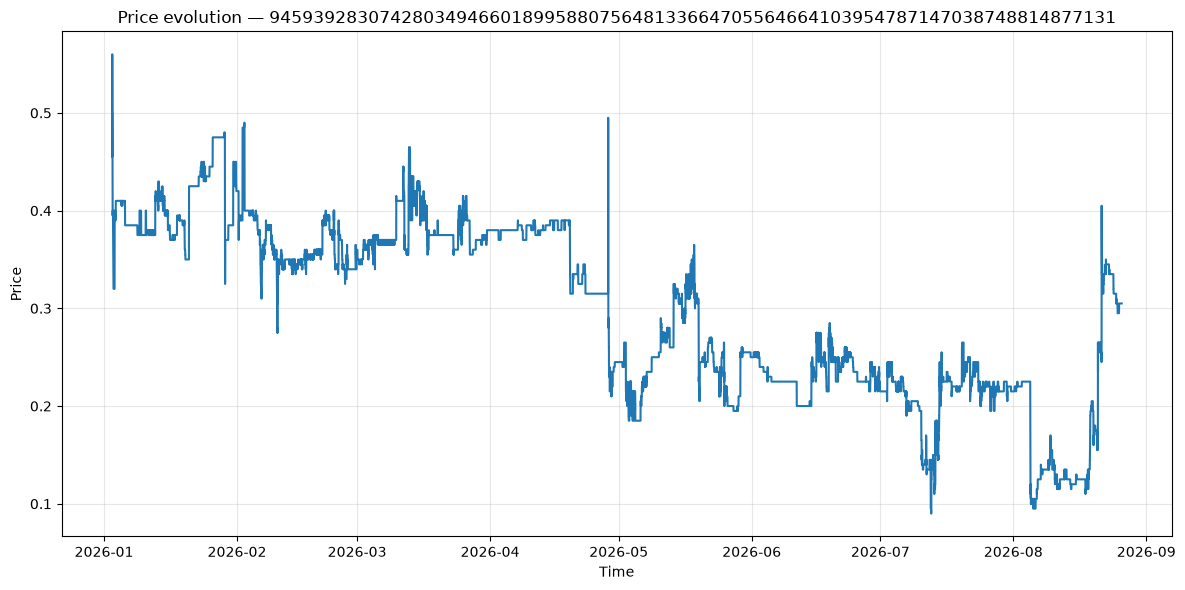

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Player/token you want
market_index = 875

# Filter to this player
player_df = price_history_df[price_history_df["market_index"] == market_index].copy()

# Convert timestamp
player_df["timestamp"] = pd.to_datetime(player_df["timestamp"], utc=True)

# Sort chronologically
player_df = player_df.sort_values("timestamp")

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    player_df["timestamp"],
    player_df["price"],
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"Price evolution — {token_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
price_history_df.to_parquet("tennis_price_history_df.parquet")